In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s6e2/sample_submission.csv
/kaggle/input/playground-series-s6e2/train.csv
/kaggle/input/playground-series-s6e2/test.csv


In [2]:
os.chdir('/kaggle/input/playground-series-s6e2/')
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.model_selection import train_test_split

In [3]:
df_train=pd.read_csv('train.csv',index_col='id')
df_train.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
id,,,,,,,,,,,,,,
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
df_train, df_val= train_test_split(df_train,random_state=42)

In [5]:
df_val.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
id,,,,,,,,,,,,,,
364426,57,1,2,120,177,0,0,132,0,1.2,2,0,3,Absence
224752,41,1,4,132,274,0,2,122,0,0.0,1,0,3,Presence
110423,63,1,4,140,239,0,2,145,1,2.2,2,1,7,Presence
272555,47,1,4,140,197,0,2,147,1,1.6,2,1,7,Presence
199651,50,0,3,140,298,0,0,152,0,0.0,1,0,3,Absence


In [6]:
x_train=df_train.drop('Heart Disease',axis=1)
x_val=df_val.drop('Heart Disease',axis=1)
preprocessor = make_column_transformer(
    (StandardScaler(),
     ['Age','BP','Cholesterol','Max HR', 'ST depression', 'Slope of ST','Number of vessels fluro']),
    (OneHotEncoder(),
     ['Chest pain type','EKG results','Thallium']),
    remainder='passthrough'
)
x_train=preprocessor.fit_transform(x_train)
x_val=preprocessor.fit_transform(x_val)

In [7]:
y_train=df_train['Heart Disease'].copy()
y_train[y_train=='Presence']=1
y_train[y_train=='Absence']=0
y_train=y_train.to_numpy(dtype='int')
y_train.shape

(472500,)

In [8]:
y_val=df_val['Heart Disease'].copy()
y_val[y_val=='Presence']=1
y_val[y_val=='Absence']=0
y_val=y_val.to_numpy(dtype='int')
y_val.shape

(157500,)

In [9]:
from tensorflow import keras
from tensorflow.keras import layers, callbacks, metrics

model = keras.Sequential([
    layers.Input([20]),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),    
    layers.Dense(64, activation='relu'),
    layers.Dense(1),
])

2026-02-11 21:41:59.239292: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770846119.495084      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770846119.572442      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770846120.194238      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770846120.194282      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770846120.194285      17 computation_placer.cc:177] computation placer alr

In [10]:
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=20, # how many epochs to wait before stopping
    restore_best_weights=True,
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[metrics.AUC()]
)

In [11]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=200,
    callbacks=[early_stopping],
    validation_data=(x_val,y_val)
)

Epoch 1/200
3692/3692 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - auc: 0.9335 - loss: 0.4160 - val_auc: 0.9501 - val_loss: 0.3508
Epoch 2/200
3692/3692 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - auc: 0.9462 - loss: 0.3386 - val_auc: 0.9507 - val_loss: 0.3175
Epoch 3/200
3692/3692 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - auc: 0.9470 - loss: 0.3207 - val_auc: 0.9494 - val_loss: 0.3154
Epoch 4/200
3692/3692 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - auc: 0.9496 - loss: 0.3138 - val_auc: 0.9514 - val_loss: 0.3067
Epoch 5/200
3692/3692 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - auc: 0.9461 - loss: 0.3254 - val_auc: 0.9508 - val_loss: 0.3016
Epoch 6/200
3692/3692 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - auc: 0.9424 - loss: 0.3391 - val_auc: 0.9465 - val_loss: 0.7746
Epoch 7/200
3692/3692 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - auc: 0.9390 - loss: 0.3586 - val_auc: 0.9514 - val_loss: 0.3304
Epoch 8/200
3692/3692 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - auc: 0.9442 - loss: 0.3323 - val_auc: 0.9523 - val_loss: 0.3006
Epoch 9/200
3692/3692 ━━

Minimum validation loss: 0.29114004969596863


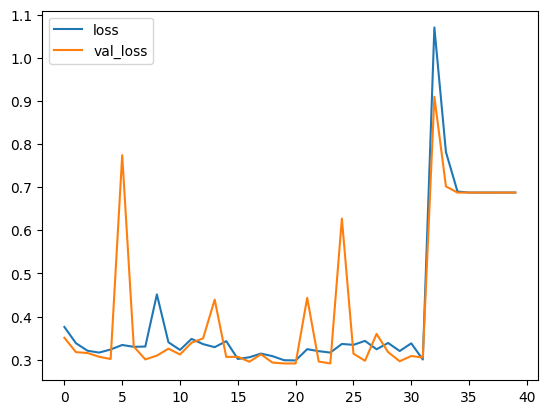

In [12]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot();
print("Minimum validation loss: {}".format(history_df['val_loss'].min()))

In [13]:
df_test=pd.read_csv('test.csv',index_col='id')
df_test.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
id,,,,,,,,,,,,,
630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [14]:
x_test=preprocessor.fit_transform(df_test)

In [15]:
y_test=model.predict(x_test)

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 8s 951us/step


In [16]:
predictions=pd.DataFrame({'id':df_test.index,'Heart Disease':y_test[:,0]})

In [17]:
os.chdir('/kaggle/working/')
predictions.to_csv('submission.csv',index=False)